In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import OPTICS
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [17]:
class DataLoader:
    def __init__(self,data:str):
        self.data = pd.read_csv(data)

    def get_data(self):
        return self.data.head()

    def get_summary(self):
        return self.data.info()

class Preprocessing(DataLoader):
    def __init__(self,data:str):
        super().__init__(data)

    def delete_col(self,col:list):
        self.data = self.data.drop(columns=col)
        return self

    def transform_data(self):
        self.num_cols = self.data.select_dtypes(include=np.number).columns
        self.cat_cols = self.data.select_dtypes(include='object').columns

        num_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
        cat_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder",OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])
        self.preprocessor = ColumnTransformer(transformers=[
            ('num',num_pipeline,self.num_cols),
            ('cat',cat_pipeline,self.cat_cols)
        ])

        self.preprocessor.set_output(transform='pandas')
        self.data = self.preprocessor.fit_transform(self.data)
        return self.data

In [18]:
processor = Preprocessing('00.dataset/Mall_Customers.csv')

remove_columns = processor.delete_col(col=["CustomerID"])

df_clean = remove_columns.transform_data()

df_clean.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


In [30]:
class OPTICSGridSearch:
    def __init__(self,min_samples:int,xi:float,min_cluster_size:float):
        self.min_samples = min_samples
        self.xi = xi
        self.min_cluster_size = min_cluster_size

    def fit_evaluated(self,X,eps_range = np.arange(0.1, 1.6, 0.1)):
        self.df_scores = pd.DataFrame()
        X_arr = X.values if isinstance(X, pd.DataFrame) else X # Konversi ke numpy array jika input berupa DataFrame

        eps_values = []
        sil_scores = []
        ch_scores = []
        db_scores = []
        n_clusters_found = []

        for eps in eps_range:
            optics = OPTICS(min_samples=self.min_samples,xi=self.xi,min_cluster_size=self.min_cluster_size,max_eps=eps,)
            labels = optics.fit_predict(X_arr)

            # Pisahkan noise (-1) dari klaster valid
            core_mask = labels != -1
            unique_labels = set(labels[core_mask])

            if len(unique_labels) >= 2:
                X_valid = X_arr[core_mask]
                labels_valid = labels[core_mask]

                eps_values.append(round(eps, 2))
                sil_scores.append(silhouette_score(X_valid, labels_valid))
                ch_scores.append(calinski_harabasz_score(X_valid, labels_valid))
                db_scores.append(davies_bouldin_score(X_valid, labels_valid))
                n_clusters_found.append(len(unique_labels))

                self.df_scores = pd.DataFrame({
                'Clusters Found': n_clusters_found,
                'eps': eps_values,
                'Silhouette Score': sil_scores,
                'Calinski-Harabasz Score': ch_scores,
                'Davies-Bouldin Score': db_scores,
                })

            if not self.df_scores.empty:
                scaler = MinMaxScaler()
                norm_sil = scaler.fit_transform(self.df_scores[['Silhouette Score']])
                norm_ch = scaler.fit_transform(self.df_scores[['Calinski-Harabasz Score']])
                norm_db = 1 - scaler.fit_transform(self.df_scores[['Davies-Bouldin Score']])
                self.df_scores['Composite_Score'] = (norm_sil + norm_ch + norm_db) / 3

        return self

    def plot_evaluation(self,figsize=(15, 11)):
        if not self.df_scores.empty:
            df = self.df_scores
            fig, axes = plt.subplots(2, 2, figsize=figsize)

            # --- Plot 1: Silhouette Score ---
            best_idx_sil = df['Silhouette Score'].idxmax()
            best_eps_sil = df.loc[best_idx_sil, 'eps']
            sns.lineplot(ax=axes[0, 0], x='eps',y='Silhouette Score',data=df,marker='o',color='#2b5c8f',)
            axes[0, 0].axvline(x=best_eps_sil,color='red',linestyle='--',label=f'Best max_eps = {best_eps_sil}',)
            axes[0, 0].set_title('Silhouette Score (Mendekati +1 Lebih Baik)', fontweight='bold')
            axes[0, 0].set_xlabel('Nilai max_eps')
            axes[0, 0].grid(True, linestyle=':', alpha=0.6)
            axes[0, 0].legend()

            # --- Plot 2: Calinski-Harabasz Score ---
            best_idx_ch = df['Calinski-Harabasz Score'].idxmax()
            best_eps_ch = df.loc[best_idx_ch, 'eps']
            sns.lineplot(ax=axes[0, 1], x='eps', y='Calinski-Harabasz Score', data=df, marker='s', color='#2e7d32')
            axes[0, 1].axvline(x=best_eps_ch, color='red', linestyle='--', label=f'Best max_eps = {best_eps_ch}')
            axes[0, 1].set_title('Calinski-Harabasz Score (Makin Tinggi Lebih Baik)', fontweight='bold')
            axes[0, 1].set_xlabel('Nilai max_eps')
            axes[0, 1].grid(True, linestyle=':', alpha=0.6)
            axes[0, 1].legend()
        
            # --- Plot 3: Davies-Bouldin Score ---
            best_idx_db = df['Davies-Bouldin Score'].idxmin()
            best_eps_db = df.loc[best_idx_db, 'eps']
            sns.lineplot(ax=axes[1, 0], x='eps', y='Davies-Bouldin Score', data=df, marker='^', color='#c62828')
            axes[1, 0].axvline(x=best_eps_db, color='green', linestyle='--', label=f'Best max_eps = {best_eps_db}')
            axes[1, 0].set_title('Davies-Bouldin Score (Makin Rendah Lebih Baik)', fontweight='bold')
            axes[1, 0].set_xlabel('Nilai max_eps')
            axes[1, 0].grid(True, linestyle=':', alpha=0.6)
            axes[1, 0].legend()
        
            # --- Plot 4: Composite Score ---
            best_idx_comp = df['Composite_Score'].idxmax()
            best_eps_comp = df.loc[best_idx_comp, 'eps']
            sns.lineplot(ax=axes[1, 1], x='eps', y='Composite_Score', data=df, marker='D', color='#7b1fa2')
            axes[1, 1].axvline(x=best_eps_comp, color='purple', linestyle='--', label=f'Rekomendasi max_eps = {best_eps_comp}')
            axes[1, 1].set_title('Normalized Composite Score (Gabungan 3 Metrik)', fontweight='bold')
            axes[1, 1].set_xlabel('Nilai max_eps')
            axes[1, 1].grid(True, linestyle=':', alpha=0.6)
            axes[1, 1].legend()

            plt.suptitle('Evaluasi Metrik Klastering OPTICS Berdasarkan max_eps', fontsize=14, fontweight='bold', y=0.98)
            plt.tight_layout()
            plt.show()
        else:
            print('Tidak ada kombinasi yang menghasilkan minimal 2 cluster non-noise.')

    def get_best_params(self):
        if not self.df_scores.empty:
            best_idx = self.df_scores['Composite_Score'].idxmax()
            return self.df_scores.loc[best_idx].to_dict()
        return None


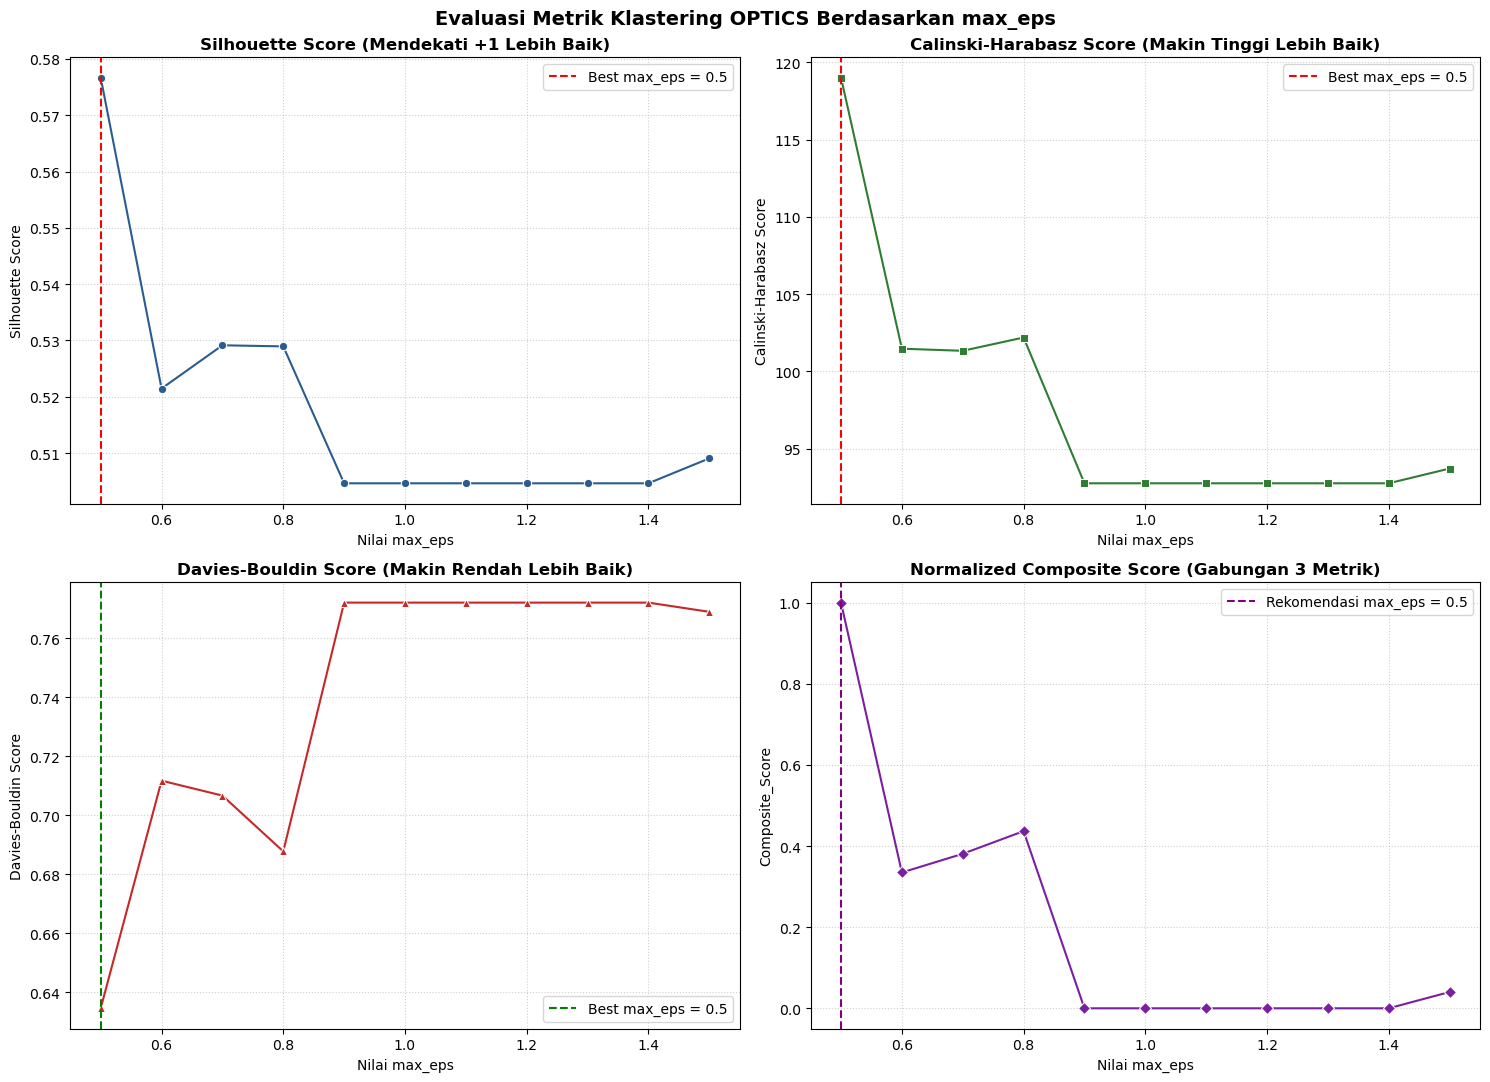

Best Configuration: {'Clusters Found': 4.0, 'eps': 0.5, 'Silhouette Score': 0.5766822276700605, 'Calinski-Harabasz Score': 119.01298271503454, 'Davies-Bouldin Score': 0.6344756000459884, 'Composite_Score': 1.0000000000000002}


In [31]:
evaluator = OPTICSGridSearch(min_samples=5, xi=0.05, min_cluster_size=0.05)

# Fit data dengan custom range eps
evaluator.fit_evaluated(df_clean, eps_range=np.arange(0.1, 1.6, 0.1))

# Tampilkan plot
evaluator.plot_evaluation()

# Dapatkan parameter rekomendasi terbaik
best_config = evaluator.get_best_params()
print('Best Configuration:', best_config)